# Линейная регрессия с разными функциями потерь

### 1. Подготовка данных с выбросами

In [1]:
# Импортируем бибилиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Генерация базовых данных
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=50,
    random_state=42
)

In [3]:
# Преобразуем в DataFrame
X = pd.DataFrame(X, columns=['feature'])
y = pd.Series(y, name='target')

# Сохраним «чистую» версию 'y' для сравнения
y_clean = y.copy()

In [4]:
# Превратим в выбросы 5% объектов
n_outliers = int(0.05 * len(y))
outlier_indices = np.random.RandomState(42).choice(y.index, size=n_outliers, replace=False)
y.loc[outlier_indices] *= 5

Text(0.5, 1.0, 'Оригинальные данные')

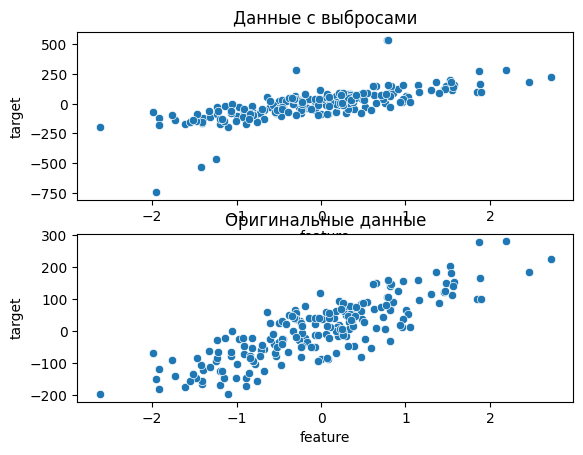

In [5]:
# Строим график разброса до и после добавления выбросов
plt.subplot(2, 1, 1)
df = X.assign(target=y)
sns.scatterplot(
    data=df,
    x='feature',
    y='target'
)
plt.title('Данные с выбросами')

plt.subplot(2, 1, 2)
df_clean = X.assign(target=y_clean)
sns.scatterplot(
    data=df_clean,
    x='feature',
    y='target'
)
plt.title('Оригинальные данные')

### 2. Разбиение на обучающую, валидационную и тестовую выборки

In [6]:
# Разделим на train_val и test
X_train_val, X_test, y_train_val, y_test = train_test_split(
                                                            X, y, test_size=0.2, random_state=42
                                                            )

# Выделите на train и val
X_train, X_val, y_train, y_val = train_test_split(
                                                  X_train_val, y_train_val, test_size=0.25, random_state=42
                                                  )

# Проверьте размерности полученных переменных
print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)

(120, 1) (40, 1) (40, 1) (120,) (40,) (40,)


### 3. Предобработка данных

In [7]:
# Создаем функцию для масштабирования
def scale_data(X_train, X_val, X_test, method='stantard'):
    if method == 'standard':
        mean = X_train.mean()
        std = X_train.std()
        X_train_scaled = (X_train - mean) / std
        X_val_scaled = (X_val - mean) / std
        X_test_scaled = (X_test - mean) / std
    elif method == 'minmax':
        min_val = X_train.min()
        max_val = X_train.max()
        X_train_scaled = (X_train - min) / (max_val - min_val)
        X_val_scaled = (X_val - min) / (max_val - min_val)
        X_test_scaled = (X_test - min) / (max_val - min_val)     
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'.")
    return X_train_scaled, X_val_scaled, X_test_scaled    

In [8]:
# Масштабирование
X_train_scaled, X_val_scaled, X_test_scaled = scale_data(X_train, X_val, X_test, 'standard')

### 4. Обучение линейной модели

In [9]:
# Модель 1 — MSE
sgd_model_mse = SGDRegressor(loss='squared_error', random_state=42)
sgd_model_mse.fit(X_train_scaled, y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [10]:
# Модель 2 — MAE
sgd_model_mae = SGDRegressor(loss='epsilon_insensitive', epsilon=0.0, random_state=42)
sgd_model_mae.fit(X_train_scaled, y_train)

c:\ProjectPython\Sprint10_Tortilla_Center\.ml-env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,loss,'epsilon_insensitive'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.0
,random_state,42


### 5. Получение предсказаний

In [11]:
# Предсказания для обучающей, валидационной и тестовой выборок
# Модель с MSE
y_train_pred_mse = sgd_model_mse.predict(X_train_scaled)
y_val_pred_mse = sgd_model_mse.predict(X_val_scaled)
y_test_pred_mse = sgd_model_mse.predict(X_test_scaled)

# Модель с MAE
y_train_pred_mae = sgd_model_mae.predict(X_train_scaled)
y_val_pred_mae = sgd_model_mae.predict(X_val_scaled)
y_test_pred_mae = sgd_model_mae.predict(X_test_scaled)

In [12]:
# Вывод средних предсказаний
print(round(y_test_pred_mse.mean(), 2))
print(round(y_test_pred_mae.mean(), 2))

-9.18
-7.27
